## Model Serving

As the class practice, the students will be required to develop local inference server using the `Churn_Modelling_train_test.csv` dataset and MLFlow for online and batch inference.

**About dataset**

This dataset is obained from [kaggle](https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction?resource=download). It contains information on bank customers who either left the bank or continue to be a customer. The dataset includes the following attributes:

* Customer ID: A unique identifier for each customer
* Surname: The customer's surname or last name
* Credit Score: A numerical value representing the customer's credit score
* Geography: The country where the customer resides (France, Spain or Germany)
* Gender: The customer's gender (Male or Female)
* Age: The customer's age.
* Tenure: The number of years the customer has been with the bank
* Balance: The customer's account balance
* NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)
* HasCrCard: Whether the customer has a credit card (1 = yes, 0 = no)
* IsActiveMember: Whether the customer is an active member (1 = yes, 0 = no)
* EstimatedSalary: The estimated salary of the customer
* Exited: Whether the customer has churned (1 = yes, 0 = no)

### Model Training

For this exercice, it is necessary to have a model registered in MLFlow. For this we can, we can use the experiments from session 2.

In [3]:
# import libraries
import os
import pandas as pd
import joblib
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import mlflow
from mlflow.models import infer_signature
import requests
import json

os.chdir("/Users/austevalentukeviciute/Desktop/MLOPS/mlops-and-system-design/")


/Users/austevalentukeviciute/Desktop/MLOPS/mlops-and-system-design/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/austevalentukeviciute/Desktop/MLOPS/mlops-and-system-design/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/austevalentukeviciute/Desktop/MLOPS/mlops-and-system-design/.venv/lib/python3.9/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with 

Start the MLflow server with the following command in the terminal: `mlflow server --host 127.0.0.1 --port 8080`.

Now, for the purpose of this exercice, you are required to define again the data transformation logic and save the one hot encoder as a `.pkl` file (if encoder was used during the pipeline).

In [4]:
# Implement transformation logic as in session 2

DROP_COLUMNS = ["RowNumber", "CustomerId", "Surname"]

def transform(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    cols_to_drop = [c for c in DROP_COLUMNS if c in df.columns]
    df = df.drop(cols_to_drop, axis=1)
    df = df[df["Geography"].notna()]
    df = df.dropna()

    encoder_path = "one_hot_encoder.pkl"
    encoder = joblib.load(encoder_path)

    # Encode both Geography and Gender using  saved encoder
    encoded = encoder.transform(df[["Geography", "Gender"]])
    df = df.drop(columns = ["Geography", "Gender"])
    df = pd.concat([df, encoded], axis=1)
    return df

In [5]:
df_validation = pd.read_csv("./session_2/Churn_Modelling_train_test.csv")
df_validation = df_validation.drop(["RowNumber", "CustomerId", "Surname"], axis=1).dropna()
df_validation["Gender"] = df_validation["Gender"].map({"Female": 1, "Male": 0})

encoder = OneHotEncoder(drop='first', sparse_output=False).set_output(transform="pandas")
encoder.fit(df_validation[["Geography"]])
joblib.dump(encoder, "one_hot_encoder.pkl")

encoded = encoder.transform(df_validation[["Geography"]])
df_validation = df_validation.drop(columns=["Geography"])
df_validation = pd.concat([df_validation, encoded], axis=1)
df_validation["Geography_nan"] = 0

X_val = df_validation.drop("Exited", axis=1)
y_val = df_validation["Exited"]
df_one_record = X_val.head(1).copy()
print(X_val.columns.tolist())

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Geography_nan']


In [6]:
df_one_record = X_val.head(1).copy()
print(df_one_record.columns.tolist())


['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Geography_nan']


In [7]:
import os
print(os.getcwd())

/Users/austevalentukeviciute/Desktop/MLOPS/mlops-and-system-design


In [8]:
import os
print(os.listdir("./"))

['churn dataset', 'exercise_support.py', 'session_2', '.DS_Store', 'requirements.txt', 'File', 'mlartifacts', 'session 2', 'mlruns', '[class notes] deployment.ipynb', '.gitignore', 'session_1', '.venv', 'task', 'one_hot_encoder.pkl', '.git']


In [9]:
print(os.listdir("./session_2"))

['.DS_Store', 'Churn_Modelling_train_test.csv', '[class notes] ml-pipeline (1).ipynb', 'FINAL VERSION of [exercise] machine-learning-pipeline.ipynb', 'bank-full_train_test (1).csv']


In [10]:
# Load training data to fit the encoder

df_train = pd.read_csv("./session_2/Churn_Modelling_train_test.csv")
df_train = df_train.drop(["RowNumber", "CustomerId", "Surname"], axis=1).dropna()

# Fit and save the encoder

df_train = pd.read_csv("./session_2/Churn_Modelling_train_test.csv")
df_train = df_train.drop(["RowNumber", "CustomerId", "Surname"], axis=1).dropna()

encoder = OneHotEncoder(drop='first', sparse_output=False).set_output(transform="pandas")
encoder.fit(df_train[["Geography", "Gender"]])
joblib.dump(encoder, "one_hot_encoder.pkl")
print(encoder.get_feature_names_out())

['Geography_Germany' 'Geography_Spain' 'Gender_Male']


In [11]:
# Perform another experiment if you don't have the ones from session 2. Otherwise, this part can be skipped

# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

### Inference

In this part, you are asked to implement a function for batch and online inference methods by providing a model uri. 

In [12]:
# import validation dataset to test inference
df_validation = pd.read_csv("./session_2/Churn_Modelling_train_test.csv")

Note that the data might need to be transformed to match the model schema. You can check the schema in the `input_example.json` file in MLFlow. 

In [13]:
# transform data - if necessary
def transform(df):
    df = df.copy()
    cols_to_drop = [c for c in ["RowNumber", "CustomerId", "Surname"] if c in df.columns]
    df = df.drop(cols_to_drop, axis=1)
    df = df.dropna()
    encoder = joblib.load("one_hot_encoder.pkl")
    encoded = encoder.transform(df[["Geography", "Gender"]])
    df = df.drop(columns=["Geography", "Gender"])
    df = pd.concat([df, encoded], axis=1)
    return df

df_validation = pd.read_csv("./session_2/Churn_Modelling_train_test.csv")

##### Batch Inference

In [14]:
# define a function to implement batch inference with mlflow
def batch_inference(model_uri: str, input: pd.DataFrame):
    model = mlflow.pyfunc.load_model(model_uri)
    predictions = model.predict(input)
    return predictions

In [15]:
# define the model uri that should be used
model_uri = "runs:/ba34f562474a4d5bb4147b2144e69bd1/churn_model"

batch_prediction_result = batch_inference(model_uri, X_val)

[[5098 2060]
 [ 338 1502]]


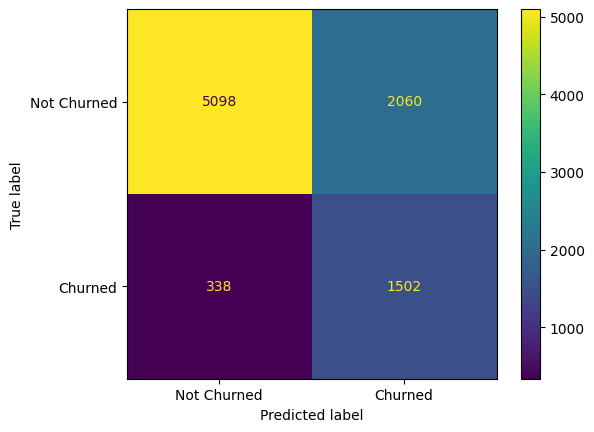

In [16]:
# check the confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, batch_prediction_result)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churned", "Churned"]).plot()
plt.show()

In [17]:
print(X_val.columns.tolist())

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Geography_nan']


##### Online Inference

For the online inference, it is required to set up local server. Follow the steps below to configure it:

1. Open a new bash terminal
2. Execute the follwing command `export MLFLOW_TRACKING_URI=http://127.0.0.1:8080` in the terminal. You should specify the port that we are using for MLFlow
3. Execute the following command `mlflow models serve -m runs:/<run_id>/model -p 5000 --no-conda`. Note that `runs:/<run_id>/model` is your model uri.

In [18]:
import requests
import json

In [19]:
# import validation dataset to test inference - just one record

df_one_record = X_val.head(1).copy()
df_one_record["Geography_nan"] = 0

# convert all columns to correct types
df_one_record = df_one_record.astype({
    "CreditScore": int,
    "Gender": int,
    "Tenure": int,
    "NumOfProducts": int,
    "HasCrCard": int,
    "IsActiveMember": int,
    "Geography_Germany": int,
    "Geography_Spain": int,
    "Geography_nan": int
})

print(df_one_record.dtypes)
print(df_one_record.values.tolist())

CreditScore            int64
Gender                 int64
Age                  float64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Geography_Germany      int64
Geography_Spain        int64
Geography_nan          int64
dtype: object
[[710.0, 1.0, 37.0, 5.0, 0.0, 2.0, 1.0, 0.0, 115403.31, 0.0, 0.0, 0.0]]


Note that the data might need to be transformed to match the model schema. You can check the schema in the `input_example.json` file in MLFlow. 

In [20]:
# transform data - if necessary

In [21]:
def get_inference_endpoint(host="http://127.0.0.1", port=5000):
    return f"{host}:{port}/invocations"

url = get_inference_endpoint()

In [22]:
# define a function to implement online inference with mlflow - pandas input

def online_inference_pandas(url: str, input: pd.DataFrame):
    payload = {"dataframe_split": input.to_dict(orient="split")}
    payload["dataframe_split"].pop("index", None)

    response = requests.post(
        url,
        headers={"Content-Type": "application/json"},
        data=json.dumps(payload)
    )
    return response

In [23]:
response_pandas = online_inference_pandas(url, df_one_record)
response_pandas.content

b'{"error_code": "INVALID_PARAMETER_VALUE", "message": "Failed to predict data \'   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan\\n0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0\\n\\n[1 rows x 12 columns]\'. \\nError: Failed to enforce schema of data \'   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan\\n0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0\\n\\n[1 rows x 12 columns]\' with schema \'[\'CreditScore\': long (required), \'Age\': double (optional), \'Tenure\': long (required), \'Balance\': double (required), \'NumOfProducts\': long (required), \'HasCrCard\': double (required), \'IsActiveMember\': double (required), \'EstimatedSalary\': dou

In [24]:
# define a function to implement online inference with mlflow - json input

def online_inference_json(url: str, input: dict):
    response = requests.post(
        url,
        headers={"Content-Type": "application/json"},
        data=json.dumps(input)
    )
    return response

In [25]:
# define the json as required by MLFlow
input_json = {
    "dataframe_split": {
        "columns": df_one_record.columns.tolist(),
        "data": [[int(v) if isinstance(v, float) and v.is_integer() else v 
                  for v in df_one_record.values.tolist()[0]]]
    }
}
print(input_json)

{'dataframe_split': {'columns': ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Geography_nan'], 'data': [[710, 1, 37, 5, 0, 2, 1, 0, 115403.31, 0, 0, 0]]}}


In [26]:
response_json = online_inference_json(url, input_json)
response_json.content

b'{"error_code": "INVALID_PARAMETER_VALUE", "message": "Failed to predict data \'   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan\\n0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0\\n\\n[1 rows x 12 columns]\'. \\nError: Failed to enforce schema of data \'   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan\\n0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0\\n\\n[1 rows x 12 columns]\' with schema \'[\'CreditScore\': long (required), \'Age\': double (optional), \'Tenure\': long (required), \'Balance\': double (required), \'NumOfProducts\': long (required), \'HasCrCard\': double (required), \'IsActiveMember\': double (required), \'EstimatedSalary\': dou

In [27]:
print(json.loads(response_json.content))

{'error_code': 'INVALID_PARAMETER_VALUE', 'message': "Failed to predict data '   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan\n0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0\n\n[1 rows x 12 columns]'. \nError: Failed to enforce schema of data '   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan\n0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0\n\n[1 rows x 12 columns]' with schema '['CreditScore': long (required), 'Age': double (optional), 'Tenure': long (required), 'Balance': double (required), 'NumOfProducts': long (required), 'HasCrCard': double (required), 'IsActiveMember': double (required), 'EstimatedSalary': double (required), 'Geography_Ger

In [28]:
print(json.loads(response_json.content)['message'])

Failed to predict data '   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan
0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0

[1 rows x 12 columns]'. 
Error: Failed to enforce schema of data '   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan
0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0

[1 rows x 12 columns]' with schema '['CreditScore': long (required), 'Age': double (optional), 'Tenure': long (required), 'Balance': double (required), 'NumOfProducts': long (required), 'HasCrCard': double (required), 'IsActiveMember': double (required), 'EstimatedSalary': double (required), 'Geography_Germany': boolean (required), 'Geography_Spain': boolean (requir

In [29]:
print(X_val.columns.tolist())

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Geography_nan']


In [30]:
print(df_one_record.dtypes)
print(df_one_record.values.tolist())

CreditScore            int64
Gender                 int64
Age                  float64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Geography_Germany      int64
Geography_Spain        int64
Geography_nan          int64
dtype: object
[[710.0, 1.0, 37.0, 5.0, 0.0, 2.0, 1.0, 0.0, 115403.31, 0.0, 0.0, 0.0]]


In [31]:
encoder_check = joblib.load("one_hot_encoder.pkl")
print(encoder_check.get_feature_names_out())

['Geography_Germany' 'Geography_Spain' 'Gender_Male']


In [32]:
batch_prediction_result = batch_inference(model_uri, X_val)
print(batch_prediction_result)

[0 0 1 ... 1 1 1]


In [33]:
response_pandas = online_inference_pandas(url, df_one_record)
print(response_pandas.content)

b'{"error_code": "INVALID_PARAMETER_VALUE", "message": "Failed to predict data \'   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan\\n0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0\\n\\n[1 rows x 12 columns]\'. \\nError: Failed to enforce schema of data \'   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan\\n0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0\\n\\n[1 rows x 12 columns]\' with schema \'[\'CreditScore\': long (required), \'Age\': double (optional), \'Tenure\': long (required), \'Balance\': double (required), \'NumOfProducts\': long (required), \'HasCrCard\': double (required), \'IsActiveMember\': double (required), \'EstimatedSalary\': dou

In [34]:
input_json = {
    "dataframe_split": {
        "columns": df_one_record.columns.tolist(),
        "data": df_one_record.values.tolist()
    }
}
response_json = online_inference_json(url, input_json)
print(response_json.content)

b'{"error_code": "INVALID_PARAMETER_VALUE", "message": "Failed to predict data \'   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan\\n0          710     1.0  37.0       5      0.0  ...             0.0        115403.31              False            False            0.0\\n\\n[1 rows x 12 columns]\'. \\nError: Failed to enforce schema of data \'   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan\\n0          710     1.0  37.0       5      0.0  ...             0.0        115403.31              False            False            0.0\\n\\n[1 rows x 12 columns]\' with schema \'[\'CreditScore\': long (required), \'Age\': double (optional), \'Tenure\': long (required), \'Balance\': double (required), \'NumOfProducts\': long (required), \'HasCrCard\': double (required), \'IsActiveMember\': double (required), \'EstimatedSalary\': dou

In [35]:
print(df_one_record.columns.tolist())

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Geography_nan']


In [37]:
df_train = pd.read_csv("./session_2/Churn_Modelling_train_test.csv")
df_train = df_train.drop(["RowNumber", "CustomerId", "Surname"], axis=1).dropna()
encoder = OneHotEncoder(drop='first', sparse_output=False).set_output(transform="pandas")
encoder.fit(df_train[["Geography"]])
joblib.dump(encoder, "one_hot_encoder.pkl")

df_validation = pd.read_csv("./session_2/Churn_Modelling_train_test.csv")
df_validation = df_validation.drop(["RowNumber", "CustomerId", "Surname"], axis=1).dropna()
df_validation["Gender"] = df_validation["Gender"].map({"Female": 1, "Male": 0})
encoded = encoder.transform(df_validation[["Geography"]])
df_validation = df_validation.drop(columns=["Geography"])
df_validation = pd.concat([df_validation, encoded], axis=1)
df_validation["Geography_nan"] = 0

X_val = df_validation.drop("Exited", axis=1)
y_val = df_validation["Exited"]
df_one_record = X_val.head(1).copy()
print(df_one_record.columns.tolist())
print(df_one_record.values.tolist())

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Geography_nan']
[[710.0, 1.0, 37.0, 5.0, 0.0, 2.0, 1.0, 0.0, 115403.31, 0.0, 0.0, 0.0]]


In [38]:
print(json.loads(response_pandas.content)['message'])

Failed to predict data '   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan
0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0

[1 rows x 12 columns]'. 
Error: Failed to enforce schema of data '   CreditScore  Gender   Age  Tenure  Balance  ...  IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  Geography_nan
0          710       1  37.0       5      0.0  ...             0.0        115403.31              False            False              0

[1 rows x 12 columns]' with schema '['CreditScore': long (required), 'Age': double (optional), 'Tenure': long (required), 'Balance': double (required), 'NumOfProducts': long (required), 'HasCrCard': double (required), 'IsActiveMember': double (required), 'EstimatedSalary': double (required), 'Geography_Germany': boolean (required), 'Geography_Spain': boolean (requir

In [39]:
df_one_record = df_one_record.astype(float)
print(df_one_record.dtypes)

CreditScore          float64
Gender               float64
Age                  float64
Tenure               float64
Balance              float64
NumOfProducts        float64
HasCrCard            float64
IsActiveMember       float64
EstimatedSalary      float64
Geography_Germany    float64
Geography_Spain      float64
Geography_nan        float64
dtype: object


In [44]:
response_pandas = online_inference_pandas(url, df_one_record)
print(response_pandas.content)

b'{"predictions": [0]}'


In [46]:
input_json = {
    "dataframe_split": {
        "columns": df_one_record.columns.tolist(),
        "data": df_one_record.values.tolist()
    }
}
response_json = online_inference_json(url, input_json)
print(response_json.content)

b'{"predictions": [0]}'


In [42]:
print(json.loads(response_pandas.content)['message'][-500:])

]' with schema '['CreditScore': long (required), 'Age': double (optional), 'Tenure': long (required), 'Balance': double (required), 'NumOfProducts': long (required), 'HasCrCard': double (required), 'IsActiveMember': double (required), 'EstimatedSalary': double (required), 'Geography_Germany': boolean (required), 'Geography_Spain': boolean (required), 'Gender_Male': boolean (required)]'. Error: Model is missing inputs ['Gender_Male']. Note that there were extra inputs: ['Geography_nan', 'Gender']


In [43]:
df_one_record = X_val.head(1).copy()

# Drop wrong columns
df_one_record = df_one_record.drop(columns=["Gender", "Geography_nan"])

# Add Gender_Male as boolean
df_one_record["Gender_Male"] = df_one_record.index.map(
    lambda i: bool(df_validation.loc[i, "Gender"] == 0)
)

# Convert Geography columns to boolean
df_one_record["Geography_Germany"] = df_one_record["Geography_Germany"].astype(bool)
df_one_record["Geography_Spain"] = df_one_record["Geography_Spain"].astype(bool)

print(df_one_record.columns.tolist())
print(df_one_record.dtypes)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
CreditScore            int64
Age                  float64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard            float64
IsActiveMember       float64
EstimatedSalary      float64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object
